### **Titanic Survival Prediction**

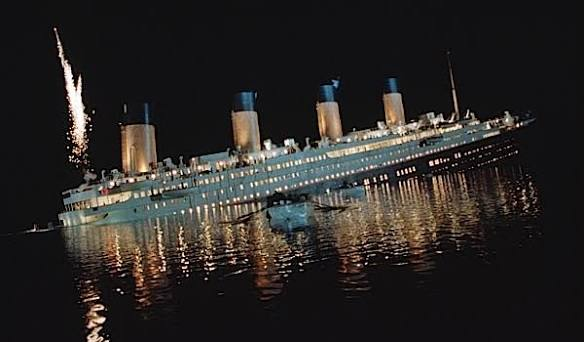

### **INTRODUCTION**

### 1. Introduction

The **Titanic dataset** is a popular dataset available on Kaggle that contains information about the passengers who were on the RMS Titanic. The ship sank after hitting an iceberg during its journey from Southampton to New York.

The dataset contains details such as the **passenger's age, gender, ticket class, fare, and survival status**. The main objective is to analyze this information and understand the factors that influenced whether a passenger **survived or did not survive** the disaster.


### 2. About the Data

The Titanic dataset contains **891 rows and 12 columns**. The columns contain both **numerical and categorical data**.

| Column          | Data Type | Description                       |
| --------------- | --------- | --------------------------------- |
| **PassengerId** | Integer   | Unique ID of each passenger       |
| **Survived**    | Integer   | Survival status: 0 = No, 1 = Yes  |
| **Pclass**      | Integer   | Passenger class: 1, 2, or 3       |
| **Name**        | String    | Passenger's name                  |
| **Sex**         | String    | Gender of the passenger           |
| **Age**         | Float     | Age of the passenger              |
| **SibSp**       | Integer   | Number of siblings/spouses aboard |
| **Parch**       | Integer   | Number of parents/children aboard |
| **Ticket**      | String    | Ticket number                     |
| **Fare**        | Float     | Ticket fare paid                  |
| **Cabin**       | String    | Cabin number                      |
| **Embarked**    | String    | Port of embarkation               |

**Numerical columns:** PassengerId, Survived, Pclass, Age, SibSp, Parch, Fare
**Categorical/String columns:** Name, Sex, Ticket, Cabin, Embarked




###3.Importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import  matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")


Mounted at /content/gdrive


In [ ]:
titanic_data=pd.read_csv("/content/gdrive/MyDrive/Colab Notebooks/train.csv")

In [ ]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_data.shape

(891, 12)

In [ ]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Age:contains 177 nan valuses out of 891 entries

Embarked: contained 2 nan values

Cabin: contains 687 nan valuses out of 891 cabin entried which basically means more than 50% of the total data exists as missing data or nans.

### **HANDLING MISSING VALUES**

**Cabin**

In [ ]:
titanic_data=titanic_data.drop(columns="Cabin",axis=1)
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


**Age**

In [ ]:
titanic_data["Age"] = titanic_data["Age"].fillna(titanic_data["Age"].mean())

In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Embarked**

In [ ]:
titanic_data["Embarked"] = titanic_data["Embarked"].fillna(titanic_data["Embarked"].mode()[0])

In [ ]:
titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**6.EDA**

In [ ]:
titanic_data.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.033207,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.069809,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.331339,0.083081,0.018443,-0.549500
Age,0.033207,-0.069809,-0.331339,1.000000,-0.232625,-0.179191,0.091566
SibSp,-0.057527,-0.035322,0.083081,-0.232625,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.179191,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.091566,0.159651,0.216225,1.000000


<Axes: >

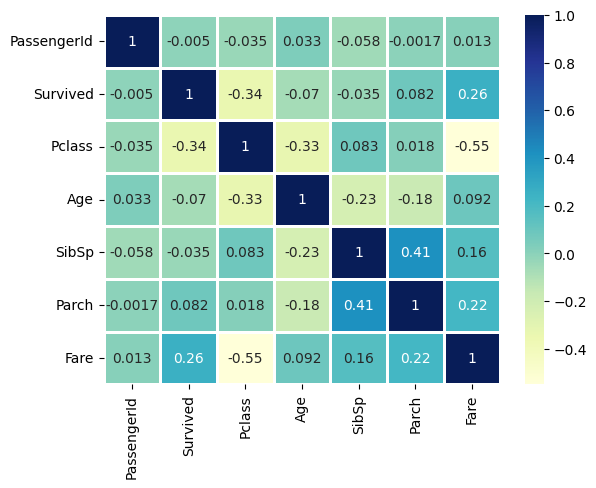

In [ ]:
sns.heatmap(titanic_data.corr(numeric_only=True),cmap="YlGnBu",annot=True,linewidth=1)

In [ ]:
titanic_data["Survived"].value_counts()

,count
Survived,
0,549
1,342


<Axes: xlabel='Survived', ylabel='count'>

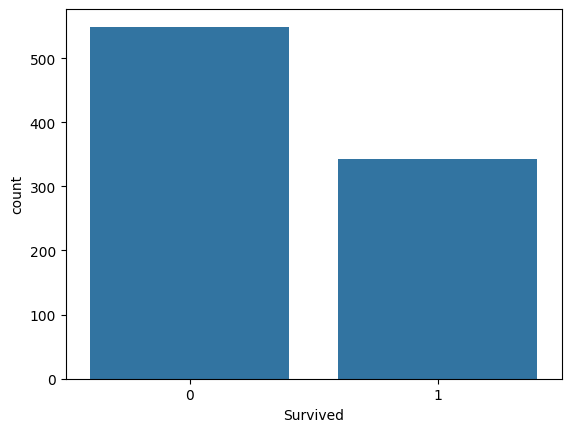

In [ ]:
sns.countplot(data=titanic_data,x="Survived")

In [ ]:
titanic_data["Sex"].value_counts()

,count
Sex,
male,577
female,314


<Axes: xlabel='Sex', ylabel='count'>

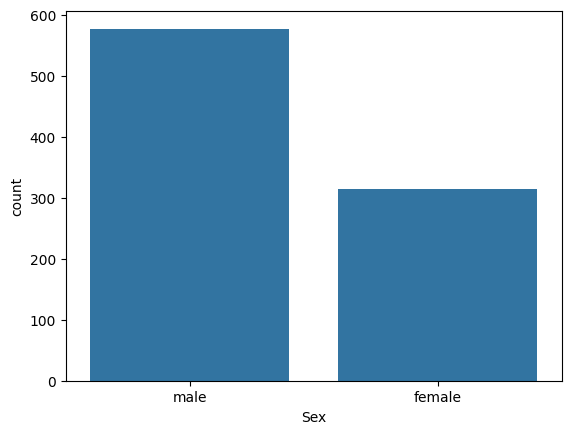

In [ ]:
sns.countplot(data=titanic_data,x="Sex")

<Axes: xlabel='Sex', ylabel='count'>

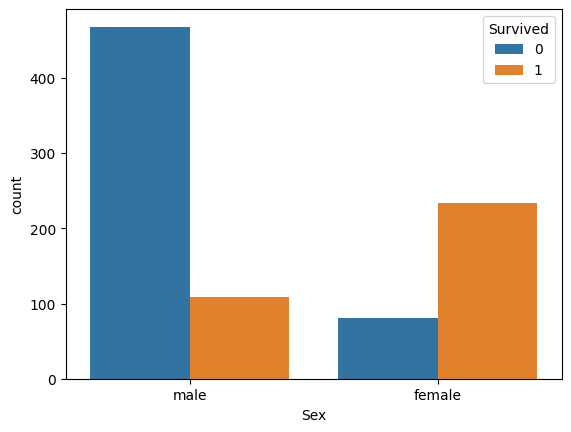

In [ ]:
sns.countplot(data=titanic_data,x="Sex",hue="Survived")

<Axes: xlabel='Pclass', ylabel='count'>

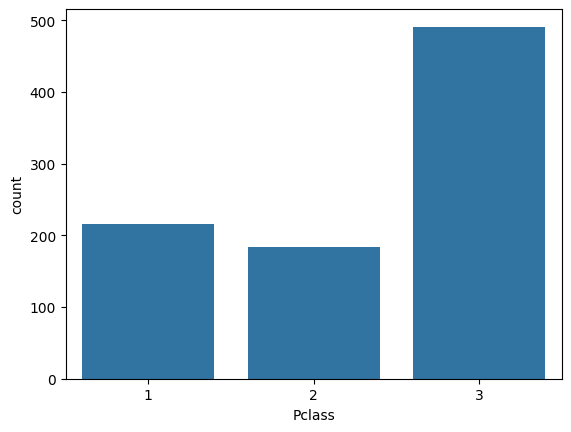

In [ ]:
sns.countplot(data=titanic_data,x="Pclass")

<Axes: xlabel='Pclass', ylabel='count'>

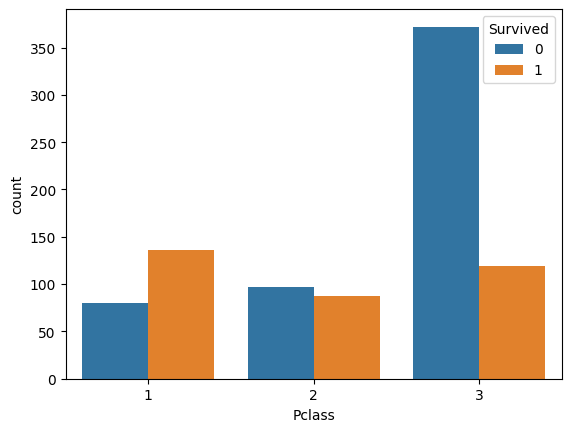

In [ ]:
sns.countplot(data=titanic_data,x="Pclass",hue="Survived")

<Axes: xlabel='Age', ylabel='Fare'>

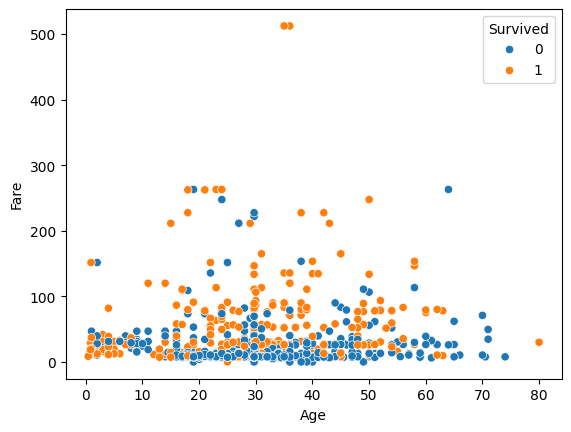

In [ ]:
sns.scatterplot(data=titanic_data,x="Age",y="Fare",hue="Survived")

<Axes: xlabel='Age', ylabel='Fare'>

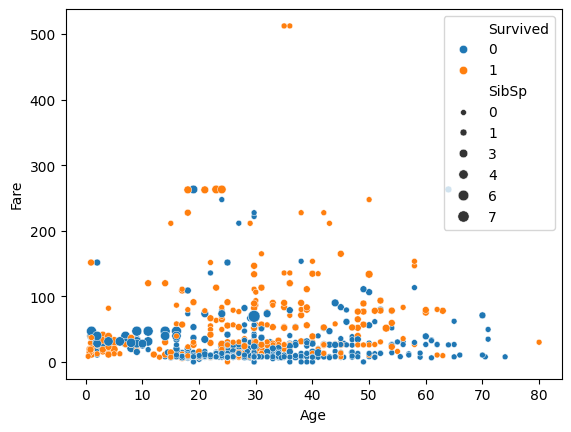

In [ ]:
sns.scatterplot(data=titanic_data,x="Age",y="Fare",hue="Survived",size="SibSp")

###**7. Feature Engineering**

In [ ]:
titanic_data.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C


**Encoding the Categorical Columns**

In [ ]:
titanic_data["Sex"].value_counts()

,count
Sex,
male,577
female,314


In [ ]:
titanic_data["Embarked"].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [31]:
titanic_data["Sex"] = titanic_data["Sex"].map({"male": 0, "female": 1})
titanic_data["Embarked"] = titanic_data["Embarked"].map({"S": 0,"C": 1,"Q": 2})

In [32]:
x=titanic_data.drop(columns=["Name","Ticket"],axis=1)

In [33]:
x.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0
3,4,1,1,1,35.0,1,0,53.1000,0
4,5,0,3,0,35.0,0,0,8.0500,0


In [34]:
x=x.replace({'Sex':{'male':0,'female':1},'Embarked': {'S':0,'C':1,'Q':2}})

In [35]:
x.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0
1,2,1,1,1,38.0,1,0,71.2833,1
2,3,1,3,1,26.0,0,0,7.9250,0


**8. Separating Features and Target**

In [36]:
X=x.drop(columns=["Survived"])

In [37]:
X.head(3)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,3,0,22.0,1,0,7.2500,0
1,2,1,1,38.0,1,0,71.2833,1
2,3,3,1,26.0,0,0,7.9250,0


In [38]:
Y=x["Survived"]

In [39]:
Y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


### **9. Splitting the data into test and train data**

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=2)

In [42]:
print(X_train.shape,X_test.shape,Y_train.shape,Y_test.shape)

(623, 8) (268, 8) (623,) (268,)


## **10. Model Selection and Training**

In [43]:
from sklearn.linear_model import LogisticRegression

In [46]:
model=LogisticRegression(max_iter=5000)

In [47]:
model.fit(X_train,Y_train)

LogisticRegression(max_iter=5000)

## **11.Model Evaluation**

In [48]:
X_train_prediction=model.predict(X_train)

In [49]:
X_train_prediction

array([0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [50]:
from sklearn.metrics import accuracy_score

In [51]:
accuracy_score(X_train_prediction,Y_train)*100

80.89887640449437

In [52]:
X_test_prediction=model.predict(X_test)

In [53]:
accuracy_score(X_test_prediction,Y_test)*100

79.47761194029852

# **Result Conclusion**

The model achieved an accuracy of 79.4%, showing that it was able to predict passenger survival reasonably well.

The analysis showed that the passengers travelling in 1st class were more likely to survive than those in 2nd and 3rd class.
Out of 891 passengers, 342 survived while 549 did not.

I learned how to clean missing data, explore patterns, visualize data, and prepare features for prediction.
Overall, the project helped me understand how data analysis and machine learning can be used to find useful patterns and make predictions.
